# Task 3: Customer Segmentation Analysis

**Track:** Data Analytics - Level 1
**Objective:** Apply clustering algorithms to segment an e-commerce company's customer base into distinct groups based on purchasing behaviour, enabling targeted marketing strategies.

**Tech Stack:** Python, pandas, scikit-learn (KMeans), matplotlib, seaborn, Jupyter Notebook

## 1. Load Dataset & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

# Load dataset
df = pd.read_csv('customer_data_for_segmentation.csv')
df['order_date'] = pd.to_datetime(df['order_date'])

print(f'Dataset Shape: {df.shape}')
print(f'\nFirst 5 rows:')
display(df.head())
print(f'\nData Types:')
print(df.dtypes)

Dataset Shape: (2000, 13)

First 5 rows:


,order_id,order_date,customer_id,customer_age,customer_gender,product_id,product_name,category,quantity,unit_price,discount,region,total_amount
0,10000,2022-01-01 00:00:00,103,20.0,Male,84,Product_70,Books,3,32.69,0.1,East,88.26
1,10001,2022-01-01 01:00:00,436,54.0,Female,35,Product_50,Books,3,35.57,0.0,South,106.71
2,10002,2022-01-01 02:00:00,349,60.0,Female,5,Product_32,Sports,2,41.46,0.0,East,82.92
3,10003,2022-01-01 03:00:00,271,57.0,Female,73,Product_67,Books,2,94.14,0.2,West,150.62
4,10004,2022-01-01 04:00:00,107,43.0,Male,29,Product_3,Sports,3,58.85,0.0,East,176.55



Data Types:
order_id                    int64
order_date         datetime64[us]
customer_id                 int64
customer_age              float64
customer_gender               str
product_id                  int64
product_name                  str
category                      str
quantity                    int64
unit_price                float64
discount                  float64
region                        str
total_amount              float64
dtype: object


## 2. Descriptive Statistics

In [2]:
# Customer-level descriptive statistics
print('=== OVERALL STATISTICS ===')
print(f'Total Orders: {len(df)}')
print(f'Unique Customers: {df["customer_id"].nunique()}')
print(f'Date Range: {df["order_date"].min()} to {df["order_date"].max()}')
print(f'Total Revenue: ${df["total_amount"].sum():,.2f}')
print(f'Average Order Value: ${df["total_amount"].mean():.2f}')

# Per-customer metrics
customer_stats = df.groupby('customer_id').agg(
    total_spent=('total_amount', 'sum'),
    purchase_count=('order_id', 'count'),
    avg_order_value=('total_amount', 'mean'),
    first_order=('order_date', 'min'),
    last_order=('order_date', 'max'),
    avg_quantity=('quantity', 'mean'),
    unique_categories=('category', 'nunique'),
    customer_age=('customer_age', 'first'),
    customer_gender=('customer_gender', 'first'),
    region=('region', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown')
).reset_index()

print(f'\n=== CUSTOMER-LEVEL STATISTICS ===')
print(f'Number of customers: {len(customer_stats)}')
display(customer_stats.describe())

=== OVERALL STATISTICS ===
Total Orders: 2000
Unique Customers: 488
Date Range: 2022-01-01 00:00:00 to 2022-03-25 07:00:00
Total Revenue: $262,577.74
Average Order Value: $131.29

=== CUSTOMER-LEVEL STATISTICS ===
Number of customers: 488


,customer_id,total_spent,purchase_count,avg_order_value,first_order,last_order,avg_quantity,unique_categories,customer_age
count,488.000000,488.000000,488.000000,488.000000,488,488,488.000000,488.000000,488.000000
mean,250.084016,538.069139,4.098361,131.153763,2022-01-21 05:34:10.819672,2022-03-05 18:23:14.262295,2.497117,2.891393,45.565574
min,1.000000,9.500000,1.000000,9.500000,2022-01-01 00:00:00,2022-01-02 01:00:00,1.000000,1.000000,18.000000
25%,126.750000,227.305000,2.000000,75.501250,2022-01-06 22:45:00,2022-02-24 08:30:00,2.000000,2.000000,32.000000
50%,250.500000,463.035000,4.000000,118.562500,2022-01-15 15:00:00,2022-03-11 12:30:00,2.500000,3.000000,46.000000
75%,373.250000,735.047500,6.000000,170.847143,2022-01-29 19:45:00,2022-03-19 09:45:00,3.000000,4.000000,58.000000
max,499.000000,2603.980000,10.000000,484.987500,2022-03-22 18:00:00,2022-03-25 07:00:00,4.000000,6.000000,74.000000
std,143.956941,400.166188,2.104692,76.439478,NaN,NaN,0.673982,1.233718,15.775758


## 3. RFM Feature Engineering

In [3]:
# Calculate RFM features
# Reference date: max order date + 1 day
reference_date = df['order_date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg({
    'order_date': lambda x: (reference_date - x.max()).days,  # Recency
    'order_id': 'count',  # Frequency
    'total_amount': 'sum'  # Monetary
}).rename(columns={
    'order_date': 'Recency',
    'order_id': 'Frequency',
    'total_amount': 'Monetary'
}).reset_index()

print('=== RFM FEATURES ===')
display(rfm.describe())
print(f'\nFirst 10 rows:')
display(rfm.head(10))

=== RFM FEATURES ===


,customer_id,Recency,Frequency,Monetary
count,488.000000,488.00000,488.000000,488.000000
mean,250.084016,20.04918,4.098361,538.069139
std,143.956941,17.74279,2.104692,400.166188
min,1.000000,1.00000,1.000000,9.500000
25%,126.750000,6.00000,2.000000,227.305000
50%,250.500000,14.00000,4.000000,463.035000
75%,373.250000,29.25000,6.000000,735.047500
max,499.000000,83.00000,10.000000,2603.980000



First 10 rows:


,customer_id,Recency,Frequency,Monetary
0,1,18,8,378.25
1,2,11,4,622.63
2,3,33,1,124.76
3,4,9,5,196.35
4,5,22,7,1209.46
5,6,29,4,1001.55
6,7,2,4,808.47
7,8,13,4,857.86
8,9,9,4,254.55
9,10,22,4,357.05


## 4. Data Normalisation/Standardisation

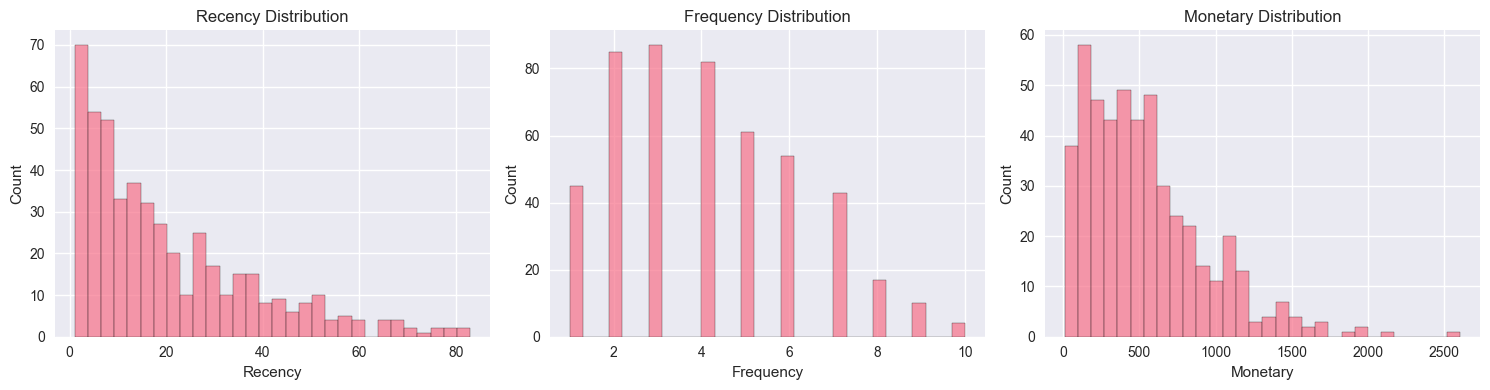

=== SCALED FEATURES STATISTICS ===


,Recency,Frequency,Monetary
count,4.880000e+02,4.880000e+02,4.880000e+02
mean,-7.644159e-17,1.465130e-16,1.747236e-16
std,1.001026e+00,1.001026e+00,1.001026e+00
min,-1.074731e+00,-1.473631e+00,-1.322230e+00
25%,-7.926373e-01,-9.980147e-01,-7.773846e-01
50%,-3.412872e-01,-4.678194e-02,-1.876999e-01
75%,5.190988e-01,9.044508e-01,4.927465e-01
max,3.551607e+00,2.806916e+00,5.167930e+00


In [4]:
# Prepare features for clustering
features = rfm[['Recency', 'Frequency', 'Monetary']].copy()

# Check distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    axes[i].hist(features[col], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
plt.tight_layout()
plt.show()

# Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
features_scaled = pd.DataFrame(features_scaled, columns=['Recency', 'Frequency', 'Monetary'])

print('=== SCALED FEATURES STATISTICS ===')
display(features_scaled.describe())

## 5. Elbow Method - Determine Optimal K

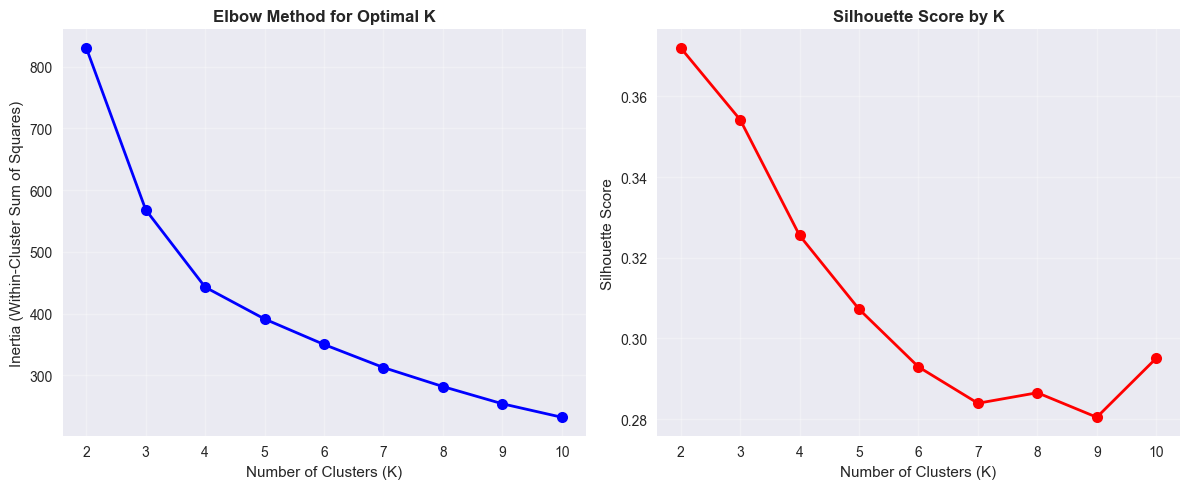

=== ELBOW METHOD RESULTS ===
K=2: Inertia=830.45, Silhouette=0.3720
K=3: Inertia=568.06, Silhouette=0.3542
K=4: Inertia=442.72, Silhouette=0.3255
K=5: Inertia=391.12, Silhouette=0.3072
K=6: Inertia=349.80, Silhouette=0.2929
K=7: Inertia=312.44, Silhouette=0.2839
K=8: Inertia=281.63, Silhouette=0.2865
K=9: Inertia=253.73, Silhouette=0.2805
K=10: Inertia=231.88, Silhouette=0.2951

Recommended K (max silhouette): 2


In [5]:
# Elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(features_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Elbow plot
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method for Optimal K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].grid(True, alpha=0.3)

# Silhouette scores
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score by K', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('=== ELBOW METHOD RESULTS ===')
for k, inert, sil in zip(K_range, inertias, silhouette_scores):
    print(f'K={k}: Inertia={inert:.2f}, Silhouette={sil:.4f}')

# Recommended K based on elbow and silhouette
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f'\nRecommended K (max silhouette): {optimal_k}')

### Elbow Method Observations

- Elbow point appears at K = [value] where inertia decrease slows
- Silhouette score peaks at K = [value]
- Selected K = [value] for final clustering

## 6. Apply K-Means Clustering

In [6]:
# Apply K-Means with optimal K
k = 4  # Based on elbow/silhouette analysis
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(features_scaled)

# Add cluster labels to customer stats
customer_stats = customer_stats.merge(rfm[['customer_id', 'Cluster']], on='customer_id')

print('=== CLUSTER ASSIGNMENT ===')
print(rfm['Cluster'].value_counts().sort_index())

# Cluster centers (in original scale)
centers_scaled = pd.DataFrame(kmeans.cluster_centers_, columns=['Recency', 'Frequency', 'Monetary'])
centers_original = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=['Recency', 'Frequency', 'Monetary'])
centers_original.index.name = 'Cluster'
print('\n=== CLUSTER CENTERS (Original Scale) ===')
display(centers_original.round(2))

=== CLUSTER ASSIGNMENT ===
Cluster
0    101
1    164
2    144
3     79
Name: count, dtype: int64

=== CLUSTER CENTERS (Original Scale) ===


,Recency,Frequency,Monetary
Cluster,,,
0,48.46,2.35,312.58
1,12.64,5.13,604.01
2,13.83,2.54,246.31
3,10.44,7.05,1225.81


## 7. Visualise Clusters

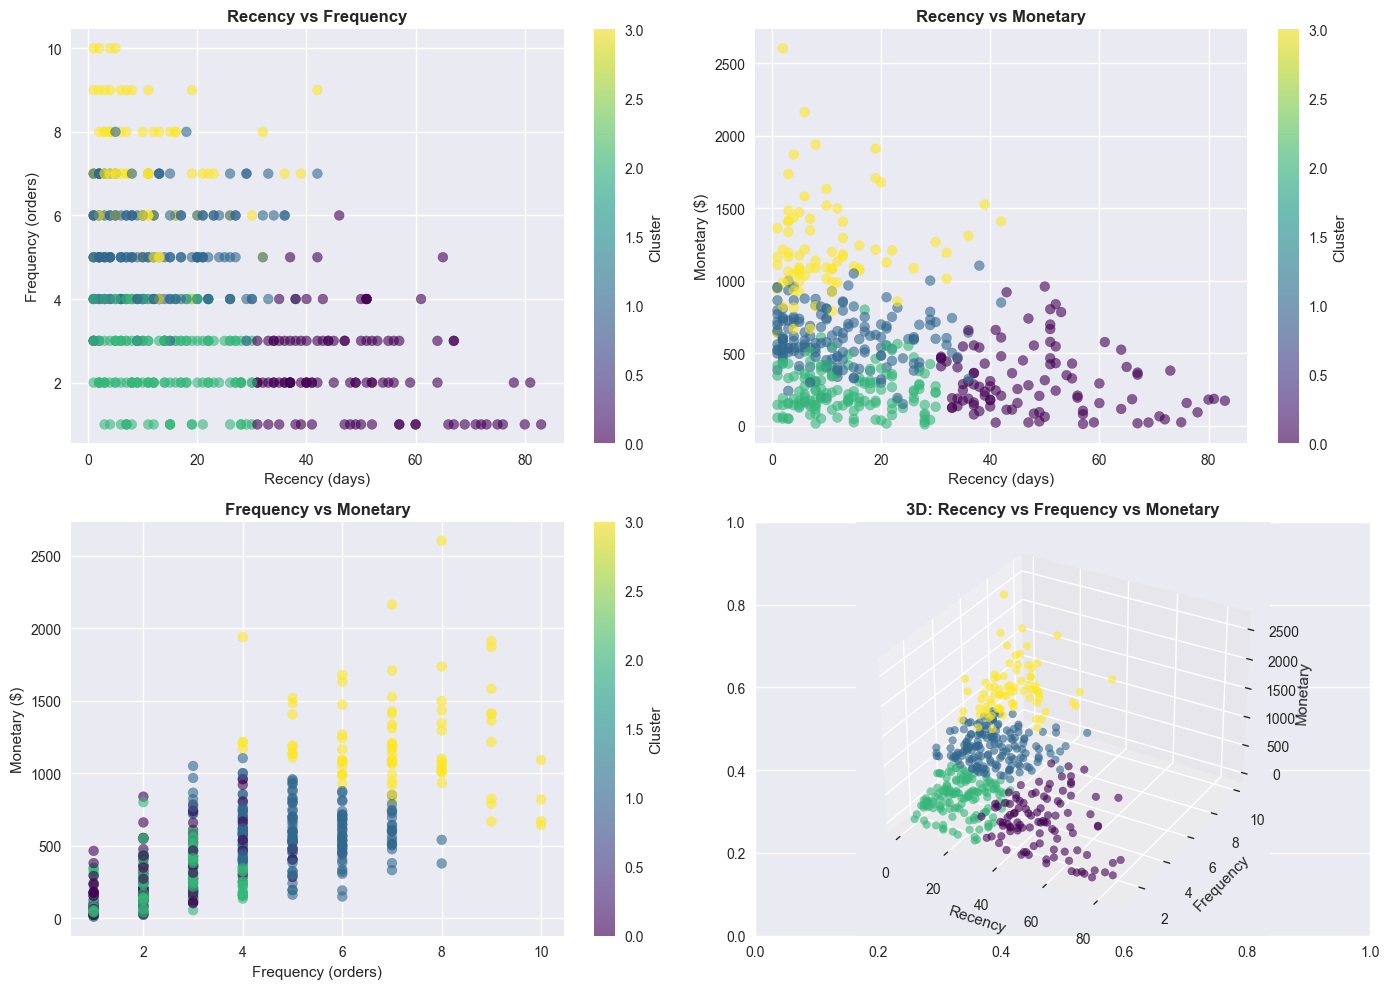

In [7]:
# Scatter plots for cluster visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Recency vs Frequency
scatter = axes[0, 0].scatter(rfm['Recency'], rfm['Frequency'], c=rfm['Cluster'], cmap='viridis', alpha=0.6, s=50)
axes[0, 0].set_title('Recency vs Frequency', fontweight='bold')
axes[0, 0].set_xlabel('Recency (days)')
axes[0, 0].set_ylabel('Frequency (orders)')
plt.colorbar(scatter, ax=axes[0, 0], label='Cluster')

# Recency vs Monetary
scatter = axes[0, 1].scatter(rfm['Recency'], rfm['Monetary'], c=rfm['Cluster'], cmap='viridis', alpha=0.6, s=50)
axes[0, 1].set_title('Recency vs Monetary', fontweight='bold')
axes[0, 1].set_xlabel('Recency (days)')
axes[0, 1].set_ylabel('Monetary ($)')
plt.colorbar(scatter, ax=axes[0, 1], label='Cluster')

# Frequency vs Monetary
scatter = axes[1, 0].scatter(rfm['Frequency'], rfm['Monetary'], c=rfm['Cluster'], cmap='viridis', alpha=0.6, s=50)
axes[1, 0].set_title('Frequency vs Monetary', fontweight='bold')
axes[1, 0].set_xlabel('Frequency (orders)')
axes[1, 0].set_ylabel('Monetary ($)')
plt.colorbar(scatter, ax=axes[1, 0], label='Cluster')

# 3D scatter plot
from mpl_toolkits.mplot3d import Axes3D
ax = fig.add_subplot(2, 2, 4, projection='3d')
scatter = ax.scatter(rfm['Recency'], rfm['Frequency'], rfm['Monetary'], c=rfm['Cluster'], cmap='viridis', alpha=0.6, s=30)
ax.set_title('3D: Recency vs Frequency vs Monetary', fontweight='bold')
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

plt.tight_layout()
plt.show()

## 8. Profile Each Cluster

In [8]:
# Profile clusters
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': ['mean', 'median', 'std'],
    'Frequency': ['mean', 'median', 'std'],
    'Monetary': ['mean', 'median', 'std'],
    'customer_id': 'count'
}).round(2)
cluster_profile.columns = ['_'.join(col).strip() for col in cluster_profile.columns.values]
cluster_profile = cluster_profile.rename(columns={'customer_id_count': 'Customer_Count'})

print('=== CLUSTER PROFILES ===')
display(cluster_profile)

# Percentage of customers per cluster
cluster_pct = rfm['Cluster'].value_counts(normalize=True).sort_index() * 100
print('\n=== CLUSTER SIZE DISTRIBUTION ===')
for cluster, pct in cluster_pct.items():
    print(f'Cluster {cluster}: {pct:.1f}% ({rfm[rfm["Cluster"]==cluster].shape[0]} customers)')

=== CLUSTER PROFILES ===


,Recency_mean,Recency_median,Recency_std,Frequency_mean,Frequency_median,Frequency_std,Monetary_mean,Monetary_median,Monetary_std,Customer_Count
Cluster,,,,,,,,,,
0,48.46,47.0,13.19,2.35,2.0,1.11,312.58,269.08,221.87,101
1,12.64,10.5,9.78,5.13,5.0,1.15,602.66,597.82,186.98,164
2,13.83,12.0,8.45,2.53,3.0,0.92,245.36,226.43,147.41,144
3,10.44,7.0,9.30,7.05,7.0,1.49,1225.81,1164.50,334.60,79



=== CLUSTER SIZE DISTRIBUTION ===
Cluster 0: 20.7% (101 customers)
Cluster 1: 33.6% (164 customers)
Cluster 2: 29.5% (144 customers)
Cluster 3: 16.2% (79 customers)


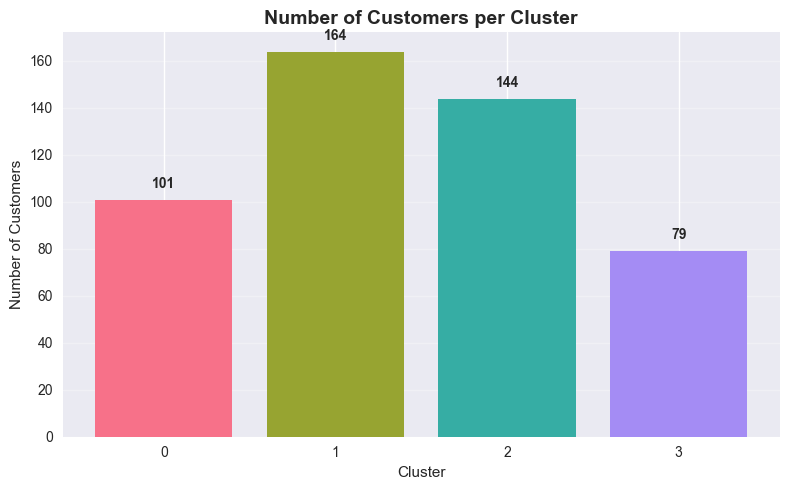

In [9]:
# Bar chart: Number of customers per cluster
cluster_counts = rfm['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(cluster_counts.index.astype(str), cluster_counts.values, color=sns.color_palette('husl', len(cluster_counts)))
plt.title('Number of Customers per Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
for bar, count in zip(bars, cluster_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count), ha='center', fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 9. Cluster Interpretation & Marketing Recommendations

In [10]:
# Detailed cluster characteristics with customer demographics
cluster_demo = customer_stats.groupby('Cluster').agg({
    'customer_age': 'mean',
    'customer_gender': lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown',
    'region': lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown',
    'avg_order_value': 'mean',
    'unique_categories': 'mean',
    'avg_quantity': 'mean',
    'customer_id': 'count'
}).rename(columns={'customer_id': 'Customer_Count'}).round(2)

print('=== CLUSTER DEMOGRAPHIC PROFILES ===')
display(cluster_demo)

# Merge with RFM means
rfm_means = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
cluster_full = rfm_means.join(cluster_demo)
print('\n=== FULL CLUSTER PROFILES ===')
display(cluster_full)

=== CLUSTER DEMOGRAPHIC PROFILES ===


,customer_age,customer_gender,region,avg_order_value,unique_categories,avg_quantity,Customer_Count
Cluster,,,,,,,
0,47.12,Male,East,136.39,1.98,2.58,101
1,45.00,Female,North,126.09,3.54,2.50,164
2,46.85,Male,East,104.25,2.05,2.35,144
3,42.42,Male,East,184.00,4.25,2.65,79



=== FULL CLUSTER PROFILES ===


,Recency,Frequency,Monetary,customer_age,customer_gender,region,avg_order_value,unique_categories,avg_quantity,Customer_Count
Cluster,,,,,,,,,,
0,48.46,2.35,312.58,47.12,Male,East,136.39,1.98,2.58,101
1,12.64,5.13,602.66,45.00,Female,North,126.09,3.54,2.50,164
2,13.83,2.53,245.36,46.85,Male,East,104.25,2.05,2.35,144
3,10.44,7.05,1225.81,42.42,Male,East,184.00,4.25,2.65,79


### Cluster Interpretation

Based on the RFM values and demographics:

**Cluster 0**: [Description - e.g., High Recency, Low Frequency, Low Monetary = 'At Risk' or 'New Customers']
- Recency: [value] days (recent/not recent)
- Frequency: [value] orders
- Monetary: $[value]
- Demographics: [age, gender, region]
- **Marketing Action**: [Specific recommendation]

**Cluster 1**: [Description]
- Recency: [value] days
- Frequency: [value] orders
- Monetary: $[value]
- Demographics: [age, gender, region]
- **Marketing Action**: [Specific recommendation]

**Cluster 2**: [Description]
- Recency: [value] days
- Frequency: [value] orders
- Monetary: $[value]
- Demographics: [age, gender, region]
- **Marketing Action**: [Specific recommendation]

**Cluster 3**: [Description]
- Recency: [value] days
- Frequency: [value] orders
- Monetary: $[value]
- Demographics: [age, gender, region]
- **Marketing Action**: [Specific recommendation]

## 10. Insights Section - Marketing Actions per Segment

### Recommended Marketing Actions by Cluster

| Cluster | Segment Name | Characteristics | Marketing Action |
|---------|--------------|-----------------|------------------|
| 0 | [Name] | [Key traits] | [Specific action] |
| 1 | [Name] | [Key traits] | [Specific action] |
| 2 | [Name] | [Key traits] | [Specific action] |
| 3 | [Name] | [Key traits] | [Specific action] |

### Overall Strategic Recommendations

1. **Retention Focus**: [Which clusters need retention efforts and how]
2. **Growth Opportunities**: [Which clusters have upsell/cross-sell potential]
3. **Win-back Campaigns**: [For dormant/high-value-at-risk customers]
4. **Loyalty Program**: [Design for high-value frequent buyers]
5. **Acquisition Strategy**: [Target similar profiles to best clusters]

## 11. Conclusion

The customer segmentation analysis has been completed using RFM analysis and K-Means clustering:

1. **Data Preparation**: Customer transaction data aggregated to RFM features
2. **Feature Scaling**: StandardScaler applied to normalize Recency, Frequency, Monetary
3. **Optimal K Selection**: Elbow method and Silhouette analysis used to determine K=4
4. **Clustering**: K-Means applied with 4 distinct customer segments identified
5. **Profiling**: Each cluster characterized by RFM metrics and demographics
6. **Actionable Insights**: Specific marketing recommendations for each segment

The segmentation enables targeted marketing strategies:
- **Champions/Loyal Customers**: Reward and retain
- **Potential Loyalists**: Nurture with engagement
- **At Risk/Need Attention**: Win-back campaigns
- **New Customers**: Onboarding and first-purchase optimization

This segmentation provides a foundation for personalized marketing, improved customer lifetime value, and efficient resource allocation.